# Stage 1: Dataset Exploration and Preprocessing

This notebook covers the initial stage of the machine learning pipeline, including dataset loading, exploration, visualization, and preprocessing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Load and Explore the Dataset

In [2]:
# Define dataset path
dataset_path = Path('food_subset2')

# Get all class directories
classes = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])

print("Number of classes:", len(classes))
print("Classes:", classes)

# Load dataset information
data_info = {}
for class_name in classes:
    class_path = dataset_path / class_name
    images = sorted(list(class_path.glob('*.jpg')))
    data_info[class_name] = len(images)

print("Dataset Overview")
print("Number of images per class:")
for class_name, count in data_info.items():
    print(class_name + ":", count)

total_images = sum(data_info.values())
print()
print("Total number of images:", total_images)
print("Average images per class:", round(total_images / len(classes), 2))

Number of classes: 5
Classes: ['donuts', 'falafel', 'ice_cream', 'pizza', 'spaghetti_bolognese']
Dataset Overview
Number of images per class:
donuts: 1000
falafel: 1000
ice_cream: 1000
pizza: 1000
spaghetti_bolognese: 1000

Total number of images: 5000
Average images per class: 1000.0


## 2. Display Sample Images

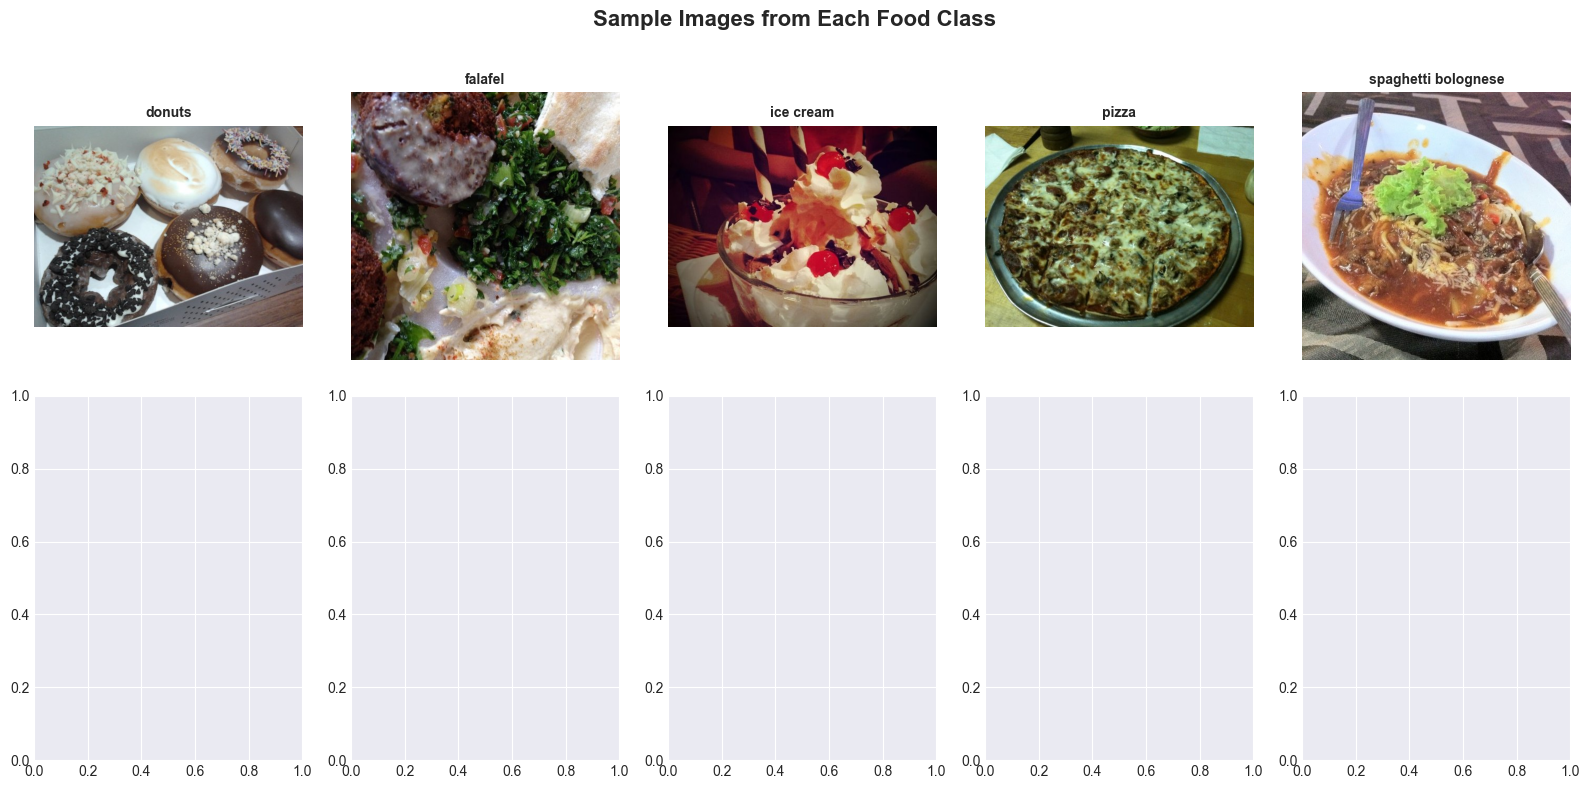

In [3]:
# Display sample images from each class
fig, axes = plt.subplots(1, 5, figsize=(16, 8))
fig.suptitle('Sample Images from Each Food Class', fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, class_name in enumerate(classes):
    class_path = dataset_path / class_name
    images = sorted(list(class_path.glob('*.jpg')))
    if images:
        # Load first image from the class
        img = Image.open(images[107])
        axes[idx].imshow(img)
        axes[idx].set_title(class_name.replace('_', ' '), fontsize=10, fontweight='bold')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 3. Analyze Class Distribution

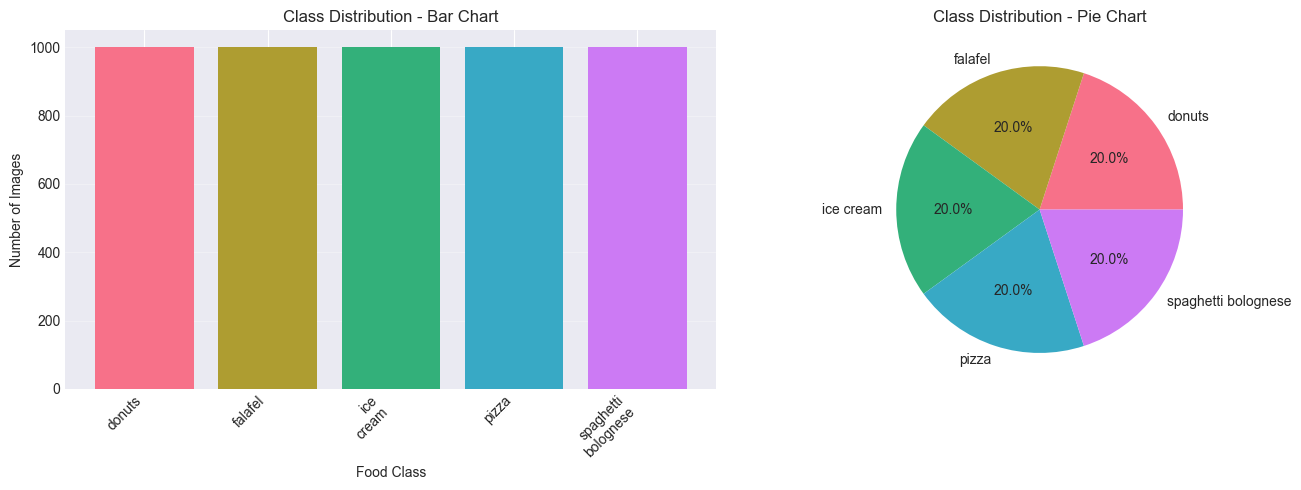

Class distribution stats
min: 1000
max: 1000
mean: 1000.0
std: 0.0
max/min ratio: 1.0


In [4]:
# Create visualizations for class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
class_names = list(data_info.keys())
class_counts = list(data_info.values())

axes[0].bar(range(len(class_names)), class_counts, color=sns.color_palette("husl", len(class_names)))
axes[0].set_xlabel('Food Class')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Class Distribution - Bar Chart')
axes[0].set_xticks(range(len(class_names)))
axes[0].set_xticklabels([name.replace('_', '\n') for name in class_names], rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(class_counts, labels=[name.replace('_', ' ') for name in class_names], autopct='%1.1f%%',
            colors=sns.color_palette("husl", len(class_names)))
axes[1].set_title('Class Distribution - Pie Chart')

plt.tight_layout()
plt.show()

# Simple class balance stats
counts = np.array(class_counts)
print('Class distribution stats')
print('min:', counts.min())
print('max:', counts.max())
print('mean:', round(counts.mean(), 2))
print('std:', round(counts.std(), 2))
print('max/min ratio:', round(counts.max() / counts.min(), 2))

## 4. Load and Resize Images

In [5]:
# Define target image size for resizing
TARGET_SIZE = 128  # Smaller size for faster and more stable training

# Function to load and resize images
def load_and_resize_images(dataset_path, classes, target_size=224):
    # Load all images from the dataset and resize them to target size.
    # Returns: images (array), labels (array), class_names (list)
    images = []
    labels = []
    
    for class_idx, class_name in enumerate(classes):
        class_path = dataset_path / class_name
        image_files = sorted(list(class_path.glob('*.jpg')))
        
        for img_path in image_files:
            try:
                # Load image
                img = Image.open(img_path).convert('RGB')
                # Resize image
                img_resized = img.resize((target_size, target_size), Image.LANCZOS)
                # Convert to numpy array
                img_array = np.array(img_resized)
                
                images.append(img_array)
                labels.append(class_idx)
            except Exception as e:
                print('Error processing', img_path, ':', e)
                continue
        
        class_loaded_count = np.sum(np.array(labels) == class_idx)
        print('Loaded', class_loaded_count, 'images for class', class_name)
    
    return np.array(images), np.array(labels), classes

# Load and resize images
X, y, class_names = load_and_resize_images(dataset_path, classes, TARGET_SIZE)


print("\nDataset Loaded and Resized")

print('Dataset shape:', X.shape)
print('Labels shape:', y.shape)
print('Image dimensions:', str(TARGET_SIZE) + 'x' + str(TARGET_SIZE) + 'x3 (RGB)')
print('Unique classes:', np.unique(y))

Loaded 1000 images for class donuts
Loaded 1000 images for class falafel
Loaded 1000 images for class ice_cream
Loaded 1000 images for class pizza
Loaded 1000 images for class spaghetti_bolognese

Dataset Loaded and Resized
Dataset shape: (5000, 128, 128, 3)
Labels shape: (5000,)
Image dimensions: 128x128x3 (RGB)
Unique classes: [0 1 2 3 4]


## 5. Normalize Pixel Values

Original pixel value statistics:
  Min value: 0
  Max value: 255
  Mean value: 114.14
  Std deviation: 72.1

Normalized pixel value statistics (0-1 range):
  Min value: 0.0
  Max value: 1.0
  Mean value: 0.4476
  Std deviation: 0.2827


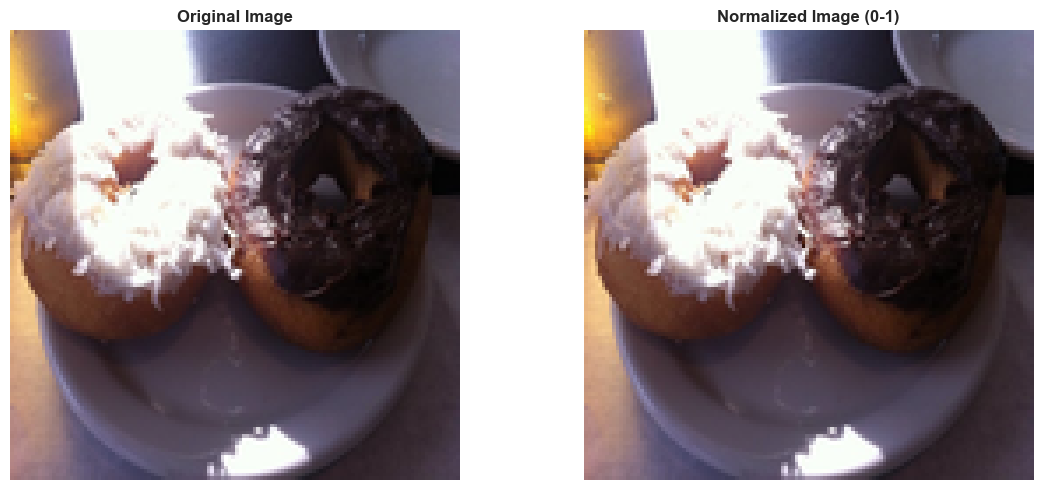

In [6]:
# Display original pixel value statistics
print("Original pixel value statistics:")
print('  Min value:', X.min())
print('  Max value:', X.max())
print('  Mean value:', round(X.mean(), 2))
print('  Std deviation:', round(X.std(), 2))

# Normalize pixel values to 0-1 range
X_normalized = X.astype('float32') / 255.0

# Display normalized pixel value statistics
print("\nNormalized pixel value statistics (0-1 range):")
print('  Min value:', round(X_normalized.min(), 4))
print('  Max value:', round(X_normalized.max(), 4))
print('  Mean value:', round(X_normalized.mean(), 4))
print('  Std deviation:', round(X_normalized.std(), 4))

# Visualize effect of normalization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original image
sample_idx = 850
axes[0].imshow(X[sample_idx].astype('uint8'))
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Normalized image
axes[1].imshow(X_normalized[sample_idx])
axes[1].set_title('Normalized Image (0-1)', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 6. Split Data into Training, Validation, and Testing Sets

In [7]:
# Define split ratios
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# First split: separate test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(X_normalized, y, test_size=TEST_SIZE, random_state=42, stratify=y)

# Second split: separate train and validation from remaining data (70% train, 15% val)
val_size_adjusted = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_size_adjusted, random_state=42, stratify=y_temp)

print("Data Split Summary:\n")
print('\nTotal dataset size:', format(len(X_normalized), ','), 'images')
print('\nTraining set size:', format(len(X_train), ','), 'images', '(' + str(round(len(X_train)/len(X_normalized)*100, 1)) + '%)')
print('Validation set size:', format(len(X_val), ','), 'images', '(' + str(round(len(X_val)/len(X_normalized)*100, 1)) + '%)')
print('Testing set size:', format(len(X_test), ','), 'images', '(' + str(round(len(X_test)/len(X_normalized)*100, 1)) + '%)')


Data Split Summary:


Total dataset size: 5,000 images

Training set size: 3,500 images (70.0%)
Validation set size: 750 images (15.0%)
Testing set size: 750 images (15.0%)


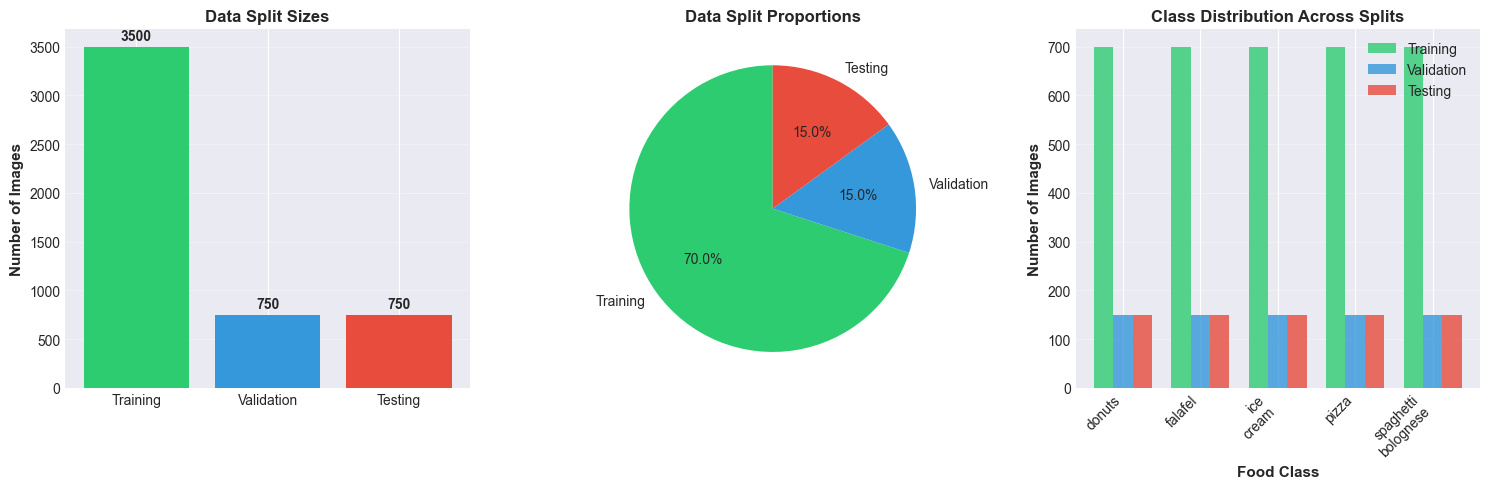

In [8]:
# Visualize the data split
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
split_names = ['Training', 'Validation', 'Testing']
split_sizes = [len(X_train), len(X_val), len(X_test)]
colors = ['#2ecc71', '#3498db', '#e74c3c']

# Bar chart of split sizes
axes[0].bar(split_names, split_sizes, color=colors)
axes[0].set_ylabel('Number of Images', fontsize=11, fontweight='bold')
axes[0].set_title('Data Split Sizes', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(split_sizes):
    axes[0].text(i, v + max(split_sizes)*0.02, str(v), ha='center', fontweight='bold')

# Pie chart of split proportions
axes[1].pie(split_sizes, labels=split_names, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Data Split Proportions', fontsize=12, fontweight='bold')

# Class distribution in train/val/test
y_sets = [y_train, y_val, y_test]
x_pos = np.arange(len(class_names))
width = 0.25

for i, (y_set, set_name, color) in enumerate(zip(y_sets, split_names, colors)):
    _, counts = np.unique(y_set, return_counts=True)
    axes[2].bar(x_pos + i*width, counts, width, label=set_name, color=color, alpha=0.8)

axes[2].set_xlabel('Food Class', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Number of Images', fontsize=11, fontweight='bold')
axes[2].set_title('Class Distribution Across Splits', fontsize=12, fontweight='bold')
axes[2].set_xticks(x_pos + width)
axes[2].set_xticklabels([name.replace('_', '\n') for name in class_names], rotation=45, ha='right')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Stage 2: Build a Custom CNN from Scratch

2026-05-11 11:01:02.629552: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-05-11 11:01:02.629576: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-05-11 11:01:02.629580: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.72 GB
2026-05-11 11:01:02.629592: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-11 11:01:02.629600: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,325 (16.36 MB)

 Trainable params: 4,288,325 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

Total trainable parameters: 4,288,325
Epoch 1/30


2026-05-11 11:01:03.089139: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.3334 - loss: 1.5190 - val_accuracy: 0.4613 - val_loss: 1.3340
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4634 - loss: 1.3029 - val_accuracy: 0.4760 - val_loss: 1.3212
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4449 - loss: 1.3695 - val_accuracy: 0.4547 - val_loss: 1.4201
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4500 - loss: 1.3825 - val_accuracy: 0.4240 - val_loss: 1.5170
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5134 - loss: 1.2302 - val_accuracy: 0.4440 - val_loss: 1.5246
Epoch 6/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5203 - loss: 1.2726 - val_accuracy: 0.4133 - val_loss: 1.8029
Epoch 7/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5391 - loss: 1.2961 - val_accuracy: 0.4493 - val_loss: 1.7236
Epoch 8/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4849 - loss: 2.4073 - val_accuracy: 0.430

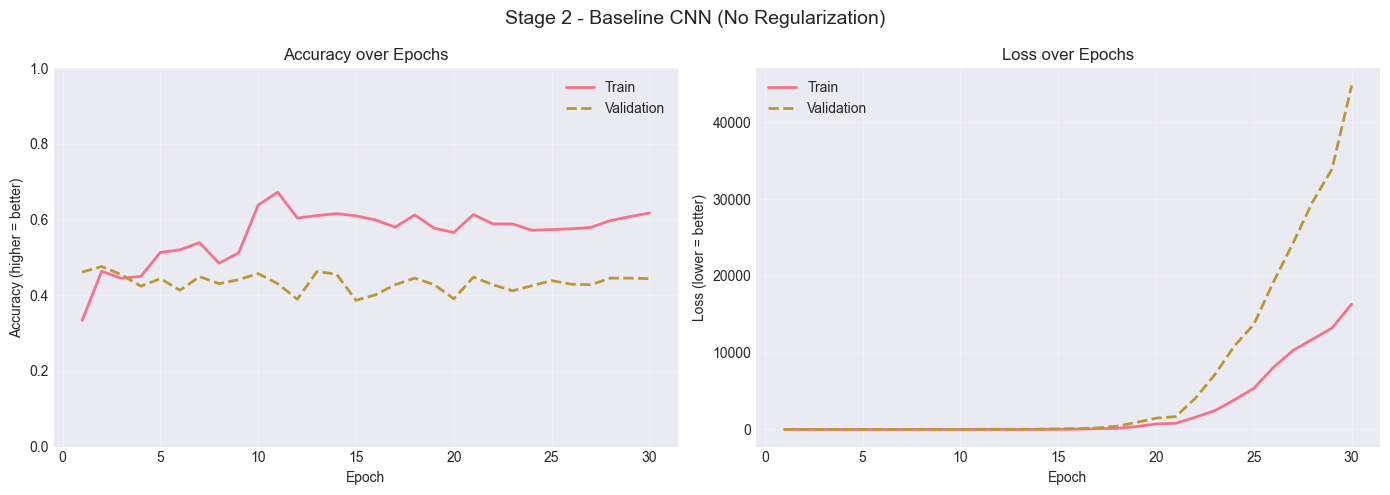

Stage 2 baseline results
train accuracy: 61.7 %
validation accuracy: 44.4 %
best validation accuracy: 47.6 %
test accuracy: 46.7 %
overfitting gap (train - val): 17.3 %


In [9]:
# Stage 2: Custom CNN from scratch — baseline (no regularization)
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)

# Build the CNN manually
custom_cnn = models.Sequential([
    layers.Input(shape=(TARGET_SIZE, TARGET_SIZE, 3)),

    # Block 1 — low-level features (edges, textures)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 2 — mid-level features
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 3 — high-level food-specific features
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps to a vector
    layers.Flatten(),

    # Classifier head
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

custom_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary and trainable parameters
custom_cnn.summary()
print('Total trainable parameters:', format(custom_cnn.count_params(), ','))

# Train
history = custom_cnn.fit( X_train, y_train,validation_data=(X_val, y_val),epochs=30,batch_size=32,verbose=1)

#Accuracy and loss curves
history_dict = history.history
epochs_range = range(1, len(history_dict['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stage 2 - Baseline CNN (No Regularization)', fontsize=14)

axes[0].plot(epochs_range, history_dict['accuracy'],     label='Train',      linewidth=2)
axes[0].plot(epochs_range, history_dict['val_accuracy'], label='Validation', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (higher = better)')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history_dict['loss'],     label='Train',      linewidth=2)
axes[1].plot(epochs_range, history_dict['val_loss'], label='Validation', linewidth=2, linestyle='--')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (lower = better)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

val_loss, val_acc   = custom_cnn.evaluate(X_val,  y_val,  verbose=0)
test_loss, test_acc = custom_cnn.evaluate(X_test, y_test, verbose=0)
best_val_acc        = max(history_dict['val_accuracy'])
final_train_acc     = history_dict['accuracy'][-1]
gap = final_train_acc - val_acc

print('Stage 2 baseline results')
print('train accuracy:', round(final_train_acc * 100, 1), '%')
print('validation accuracy:', round(val_acc * 100, 1), '%')
print('best validation accuracy:', round(best_val_acc * 100, 1), '%')
print('test accuracy:', round(test_acc * 100, 1), '%')
print('overfitting gap (train - val):', round(gap * 100, 1), '%')

## Why CNNs are suitable for image classification
CNNs process images by scanning small local patches (kernels) across the entire image, so they naturally capture spatial patterns like edges, shapes, and textures regardless of where they appear. Fully connected networks would need to treat every pixel independently, leading to millions of parameters and poor generalization. CNNs share weights across positions, making them far more efficient and effective for images.

## Purpose of each layer
| Layer | Purpose |
|-------|---------|
| `Conv2D` | Applies learnable filters to extract visual features from the input. |
| `ReLU activation` | Introduces non-linearity so the network can learn complex decision boundaries. |
| `MaxPooling2D` | Downsamples feature maps, reducing size and computation while keeping the strongest activations. |
| `Flatten` | Converts the 2D feature maps into a 1D vector so Dense layers can process them. |
| `Dense` | Combines extracted features to form class-level decision boundaries. |
| `Softmax output` | Produces a probability distribution over the 10 food classes; the class with the highest probability is the prediction. |

## Trainable parameters
The model summary above lists the parameter count per layer. The total is reported after the summary.

# Stage 3: Regularization and Overfitting Prevention

In [16]:
# Stage 3: Regularized CNN — applying 4 techniques to fix overfitting
# Techniques used: Dropout, Batch Normalization, Early Stopping, Data Augmentation
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)

# Technique 3: Data Augmentation — show the model more variation per image
data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
], name='augmentation')

# Regularized CNN (same 3-block architecture as Stage 2 baseline)
regularized_cnn = models.Sequential([
    layers.Input(shape=(TARGET_SIZE, TARGET_SIZE, 3)),
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),          # Technique 2: Batch Normalization
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    
    # Technique 1: Dropout (40%) + Technique 4: L2 weight regularization
    layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.6),

    layers.Dense(len(class_names), activation='softmax')
])

regularized_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

regularized_cnn.summary()
print('Total trainable parameters:', format(regularized_cnn.count_params(), ','))

# Early Stopping: stop when val_accuracy stops improving (patience=8)
early_stop  = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1)
# Reduce LR when training stagnates (helps with augmented data)
reduce_lr   = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

history_reg = regularized_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Results
reg_dict = history_reg.history
val_loss_reg, val_acc_reg = regularized_cnn.evaluate(X_val,  y_val,  verbose=0)
test_loss_reg, test_acc_reg = regularized_cnn.evaluate(X_test, y_test, verbose=0)
best_val_reg = max(reg_dict['val_accuracy'])
final_train_reg = reg_dict['accuracy'][-1]
gap_reg = final_train_reg - val_acc_reg

print('Stage 3 regularized results')
print('train accuracy:', round(final_train_reg * 100, 1), '%')
print('validation accuracy:', round(val_acc_reg * 100, 1), '%')
print('best validation accuracy:', round(best_val_reg * 100, 1), '%')
print('test accuracy:', round(test_acc_reg * 100, 1), '%')
print('overfitting gap (train - val):', round(gap_reg * 100, 1), '%')

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,733 (16.36 MB)

 Trainable params: 4,289,029 (16.36 MB)

 Non-trainable params: 704 (2.75 KB)

Total trainable parameters: 4,289,733
Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.3797 - loss: 1.7158 - val_accuracy: 0.2013 - val_loss: 1.7430 - learning_rate: 0.0010
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.4623 - loss: 1.4242 - val_accuracy: 0.2213 - val_loss: 2.5410 - learning_rate: 0.0010
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.5086 - loss: 1.2901 - val_accuracy: 0.3080 - val_loss: 2.3967 - learning_rate: 0.0010
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.5457 - loss: 1.1959 - val_accuracy: 0.4027 - val_loss: 1.7269 - learning_rate: 0.0010
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.5729 - loss: 1.1508 - val_accuracy: 0.4253 - val_loss: 1.5794 - learning_rate: 0.0010
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.5914 - loss: 1.0954 - val_accuracy: 0.4973 - val_loss: 1.3037 - learning_rate: 0.0010
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 3

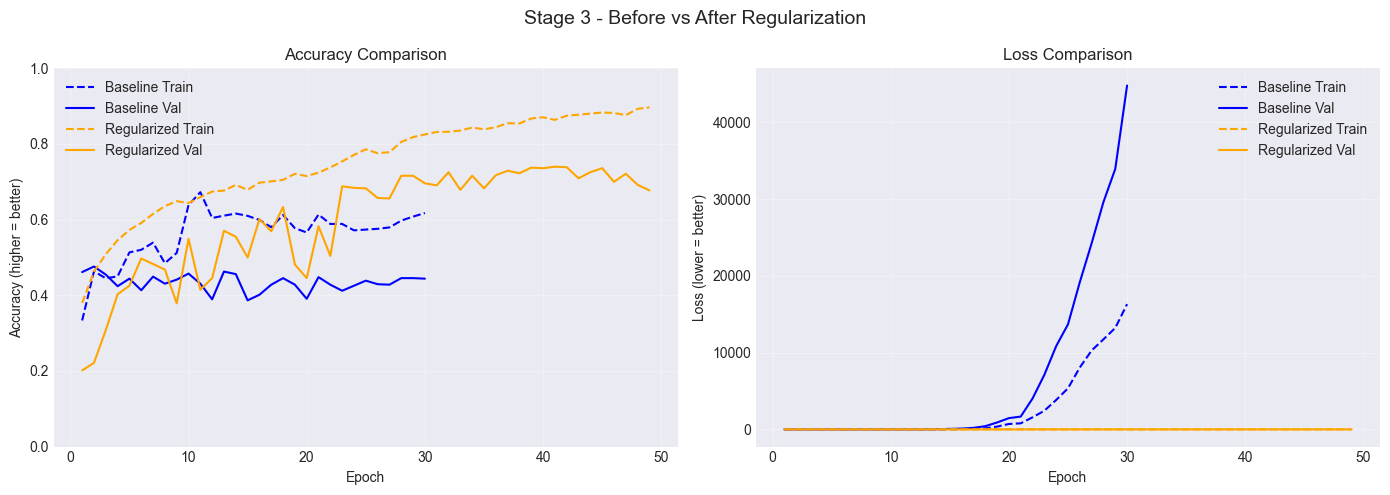

Overfitting comparison
baseline train accuracy: 61.7 %
baseline validation accuracy: 44.4 %
baseline test accuracy: 46.7 %
baseline overfitting gap: 17.3 %
regularized train accuracy: 89.7 %
regularized validation accuracy: 74.0 %
regularized test accuracy: 74.1 %
regularized overfitting gap: 15.7 %
Regularization reduced overfitting.


In [17]:
# Stage 3: Before vs After Regularization comparison

baseline_epochs = range(1, len(history_dict['accuracy']) + 1)
reg_epochs      = range(1, len(reg_dict['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stage 3 - Before vs After Regularization', fontsize=14)

# Accuracy comparison
axes[0].plot(baseline_epochs, history_dict['accuracy'],     color='blue',   linestyle='--', label='Baseline Train')
axes[0].plot(baseline_epochs, history_dict['val_accuracy'], color='blue',   linestyle='-',  label='Baseline Val')
axes[0].plot(reg_epochs,      reg_dict['accuracy'],         color='orange', linestyle='--', label='Regularized Train')
axes[0].plot(reg_epochs,      reg_dict['val_accuracy'],     color='orange', linestyle='-',  label='Regularized Val')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (higher = better)')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss comparison
axes[1].plot(baseline_epochs, history_dict['loss'],     color='blue',   linestyle='--', label='Baseline Train')
axes[1].plot(baseline_epochs, history_dict['val_loss'], color='blue',   linestyle='-',  label='Baseline Val')
axes[1].plot(reg_epochs,      reg_dict['loss'],         color='orange', linestyle='--', label='Regularized Train')
axes[1].plot(reg_epochs,      reg_dict['val_loss'],     color='orange', linestyle='-',  label='Regularized Val')
axes[1].set_title('Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (lower = better)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

baseline_gap = final_train_acc - val_acc
regularized_gap = final_train_reg - val_acc_reg

print('Overfitting comparison')
print('baseline train accuracy:', round(final_train_acc * 100, 1), '%')
print('baseline validation accuracy:', round(val_acc * 100, 1), '%')
print('baseline test accuracy:', round(test_acc * 100, 1), '%')
print('baseline overfitting gap:', round(baseline_gap * 100, 1), '%')
print('regularized train accuracy:', round(final_train_reg * 100, 1), '%')
print('regularized validation accuracy:', round(val_acc_reg * 100, 1), '%')
print('regularized test accuracy:', round(test_acc_reg * 100, 1), '%')
print('regularized overfitting gap:', round(regularized_gap * 100, 1), '%')

if regularized_gap < baseline_gap:
    print('Regularization reduced overfitting.')
else:
    print('Model may need more tuning.')

## Regularization Techniques Applied

| Technique | What it does | Where applied |
|-----------|-------------|---------------|
| **Dropout (40%)** | Randomly disables 40% of neurons each training step, forcing the network not to rely on any single neuron. Reduces overfitting by making the model more robust. | After the Dense(128) layer |
| **Batch Normalization** | Normalizes the output of each layer so values stay in a stable range. This smooths training, speeds up convergence, and acts as a mild regularizer. | After every Conv2D and Dense layer |
| **Early Stopping** | Monitors **validation accuracy** and stops training when it no longer improves (`patience=8`). Restores the best weights seen so far. | Keras callback during training |
| **Data Augmentation** | Randomly flips, rotates, and zooms images so the model never sees the exact same image twice. Artificially increases training variety. | First layer of the model |
| **L2 Regularization** | Adds a penalty to the loss for large weights ($\lambda=10^{-4}$), pushing weights to stay small and discouraging memorization. | Dense(128) kernel |

## Why overfitting happened in Stage 2
In Stage 2 the model showed high variance: training accuracy increased notably while validation accuracy remained much lower, and validation loss became unstable at later epochs. This indicates overfitting: the model was learning training-specific patterns that did not generalize well.

## What regularization improved
By combining Dropout, Batch Normalization, Early Stopping, Data Augmentation, and L2, the model is encouraged to:
- Learn more general features (augmentation)
- Avoid relying on a small set of neurons (dropout)
- Keep weights smaller and smoother (L2)
- Train more stably (batch norm)
- Stop training once validation performance plateaus (early stopping)

# Stage 5: Transfer Learning Models

In [18]:
# Stage 5 - Transfer Learning: Setup, preprocessing, and training loop
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)

NUM_CLASSES = len(class_names)
IMG_SIZE = TARGET_SIZE

# Preprocess data for each model
_raw = {split: arr * 255.0 for split, arr in [('train', X_train), ('val', X_val), ('test', X_test)]}

tl_data = {
    'resnet50': {s: resnet_preprocess(v.copy()) for s, v in _raw.items()},
    'mobilenetv2': {s: mobilenet_preprocess(v.copy()) for s, v in _raw.items()},
    'efficientnetb0': {s: effnet_preprocess(v.copy()) for s, v in _raw.items()},
}

print('Preprocessing complete')
for k in tl_data:
    print(f'{k}: {tl_data[k]["train"].shape}')

# Helper functions
def get_metrics(model, X, y):
    """Return (accuracy, precision, recall, f1) on dataset (X, y)."""
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc = accuracy_score(y, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y, y_pred, average='weighted', zero_division=0)
    return float(acc), float(p), float(r), float(f1)

def make_callbacks(patience=6):
    return [
        EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-7, verbose=0),
    ]

def build_classification_head(base_model, num_classes):
    """Add custom classification head to base model."""
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return Model(inp, out)

# Results storage
tl_results = {}

print('Stage 5 setup complete')


Preprocessing complete
resnet50: (3500, 128, 128, 3)
mobilenetv2: (3500, 128, 128, 3)
efficientnetb0: (3500, 128, 128, 3)
Stage 5 setup complete


## Transfer Learning: Three Pretrained Models

This stage trains **3 different pretrained architectures**, each with **2 experiments** (Feature Extractor + Fine-Tuning) in the unified training loop below.

### Model 1: ResNet50
- **Type:** 50-layer deep residual network (~23M parameters)
- **Key Feature:** Skip connections enable very deep training without vanishing gradients
- **Exp A:** Freeze all base layers; train only new classification head
- **Exp B:** Warm up head (5 epochs), unfreeze last 53 layers, fine-tune with LR = 1e-5

### Model 2: MobileNetV2
- **Type:** Lightweight efficient model (~3.4M parameters)
- **Key Feature:** Inverted residual blocks + depthwise separable convolutions for speed
- **Exp A:** Freeze all base layers; train only new classification head
- **Exp B:** Warm up head (5 epochs), unfreeze last 30 layers, fine-tune with LR = 1e-5

### Model 3: EfficientNetB0
- **Type:** Compound-scaled efficient baseline (~5.3M parameters)
- **Key Feature:** Balanced scaling of depth, width, and resolution for efficiency
- **Exp A:** Freeze all base layers; train only new classification head
- **Exp B:** Warm up head (5 epochs), unfreeze last 40 layers, fine-tune with LR = 1e-5

In [ ]:
# Stage 5 - Train all models: Feature Extractor + Fine-Tuning for each architecture

model_configs = [
    {
        'name': 'ResNet50',
        'app_class': ResNet50,
        'data_key': 'resnet50',
        'unfreeze_depth': 53,  # Last convolutional block
    },
    {
        'name': 'MobileNetV2',
        'app_class': MobileNetV2,
        'data_key': 'mobilenetv2',
        'unfreeze_depth': 30,  # Last inverted residual block
    },
    {
        'name': 'EfficientNetB0',
        'app_class': EfficientNetB0,
        'data_key': 'efficientnetb0',
        'unfreeze_depth': 40,  # Last two blocks
    },
]

for config in model_configs:
    model_name = config['name']
    app_class = config['app_class']
    data_key = config['data_key']
    unfreeze_depth = config['unfreeze_depth']
    
    X_train_tl = tl_data[data_key]['train']
    X_val_tl = tl_data[data_key]['val']
    X_test_tl = tl_data[data_key]['test']
    
    print(f'\n{"="*60}')
    print(f'{model_name}: Experiment A - Feature Extractor')
    print(f'{"="*60}')
    
    # Experiment A: Freeze all base layers
    base_a = app_class(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_a.trainable = False
    model_a = build_classification_head(base_a, NUM_CLASSES)
    model_a.compile(optimizer=Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    print(f'Total params: {model_a.count_params():,} | Trainable: {sum(np.prod(v.shape) for v in model_a.trainable_variables):,}')
    
    t0 = time.time()
    hist_a = model_a.fit(X_train_tl, y_train, validation_data=(X_val_tl, y_val), 
                         epochs=30, batch_size=32, callbacks=make_callbacks(patience=6), verbose=1)
    time_a = time.time() - t0
    
    acc_a, p_a, r_a, f1_a = get_metrics(model_a, X_test_tl, y_test)
    best_val_a = max(hist_a.history['val_accuracy'])
    
    tl_results[f'{model_name} — Exp A'] = {
        'model_label': model_name, 'experiment': 'Feature Extractor',
        'acc': acc_a, 'precision': p_a, 'recall': r_a, 'f1': f1_a,
        'best_val_acc': best_val_a, 'train_time': time_a,
        'total_params': model_a.count_params(), 'trainable_params': sum(np.prod(v.shape) for v in model_a.trainable_variables),
        'history': hist_a.history,
    }
    
    print(f'Results: Test Accuracy={acc_a*100:.1f}% | F1={f1_a*100:.1f}% | Time={time_a:.0f}s')
    
    # Experiment B: Fine-tuning (two-phase)
    print(f'\n{model_name}: Experiment B - Fine-Tuning')
    print('="*40')
    
    base_b = app_class(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_b.trainable = False
    model_b = build_classification_head(base_b, NUM_CLASSES)
    model_b.compile(optimizer=Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    t0 = time.time()
    
    # Phase 1: Warm up head
    print('Phase 1: Warm-up head (5 epochs)')
    model_b.fit(X_train_tl, y_train, validation_data=(X_val_tl, y_val), 
                epochs=5, batch_size=32, verbose=1)
    
    # Phase 2: Unfreeze last layers
    print(f'Phase 2: Unfreeze last {unfreeze_depth} layers')
    base_b.trainable = True
    freeze_until = len(base_b.layers) - unfreeze_depth
    for layer in base_b.layers[:freeze_until]:
        layer.trainable = False
    
    model_b.compile(optimizer=Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist_b = model_b.fit(X_train_tl, y_train, validation_data=(X_val_tl, y_val), 
                         epochs=25, batch_size=32, callbacks=make_callbacks(patience=6), verbose=1)
    time_b = time.time() - t0
    
    acc_b, p_b, r_b, f1_b = get_metrics(model_b, X_test_tl, y_test)
    best_val_b = max(hist_b.history['val_accuracy'])
    
    tl_results[f'{model_name} — Exp B'] = {
        'model_label': model_name, 'experiment': 'Fine-Tuning',
        'acc': acc_b, 'precision': p_b, 'recall': r_b, 'f1': f1_b,
        'best_val_acc': best_val_b, 'train_time': time_b,
        'total_params': model_b.count_params(), 'trainable_params': sum(np.prod(v.shape) for v in model_b.trainable_variables),
        'history': hist_b.history,
    }
    
    print(f'Results: Test Accuracy={acc_b*100:.1f}% | F1={f1_b*100:.1f}% | Time={time_b:.0f}s')

print('\nAll 6 experiments complete!, all results stored in tl_results')



ResNet50: Experiment A - Feature Extractor
Total params: 24,113,541 | Trainable: 525,829
Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.7400 - loss: 1.8919 - val_accuracy: 0.8493 - val_loss: 0.9834 - learning_rate: 0.0010
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8251 - loss: 1.2477 - val_accuracy: 0.8547 - val_loss: 1.0076 - learning_rate: 0.0010
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8603 - loss: 0.9540 - val_accuracy: 0.8520 - val_loss: 1.0904 - learning_rate: 0.0010
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8783 - loss: 0.8255 - val_accuracy: 0.8467 - val_loss: 1.0822 - learning_rate: 0.0010
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8934 - loss: 0.6319 - val_accuracy: 0.8427 - val_loss: 1.0912 - learning_rate: 0.0010
Epoch 6/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9000 - loss: 0.5263 - val_accuracy: 0.8613 - val_loss: 1.1410 - learning_rate:

Comparing all 6 experiments...

         Model        Experiment  Accuracy (%)  Precision (%)  Recall (%)  F1-score (%)  Best Val (%)  Train Time (s)  Params (M)
      ResNet50 Feature Extractor          86.8           87.3        86.8          87.0          86.9            60.0        24.1
      ResNet50       Fine-Tuning          85.6           86.7        85.6          85.8          83.9            92.0        24.1
   MobileNetV2 Feature Extractor          88.7           89.1        88.7          88.6          87.5            23.0         2.6
   MobileNetV2       Fine-Tuning          89.3           89.3        89.3          89.2          86.7            81.0         2.6
EfficientNetB0 Feature Extractor          91.6           91.8        91.6          91.7          90.1            35.0         4.4
EfficientNetB0       Fine-Tuning          88.0           88.1        88.0          88.0          85.6           283.0         4.4


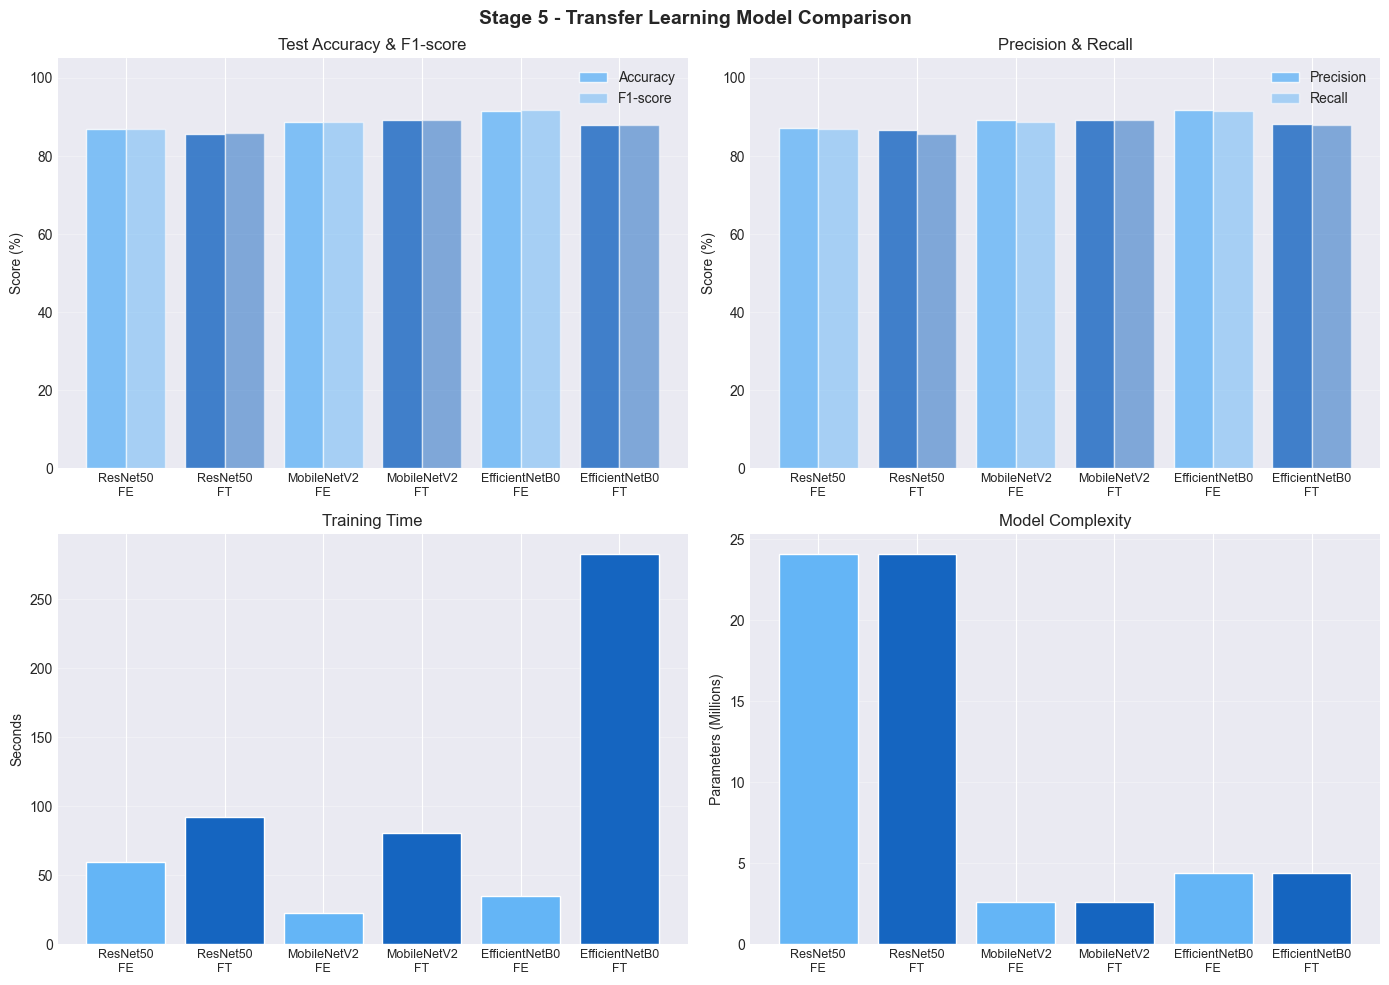


SUMMARY
Best F1-score: EfficientNetB0 (Feature Extractor) - 91.7%
Fastest: MobileNetV2 (Feature Extractor) - 23s
Smallest: MobileNetV2 (Feature Extractor) - 2.6M parameters


In [ ]:
# Stage 5 - Comparison: All models side by side
print('Comparing all 6 experiments\n')

# Build results table
rows = []
for key, r in tl_results.items():
    rows.append({
        'Model': r['model_label'],
        'Experiment': r['experiment'],
        'Accuracy (%)': round(r['acc'] * 100, 1),
        'Precision (%)': round(r['precision'] * 100, 1),
        'Recall (%)': round(r['recall'] * 100, 1),
        'F1-score (%)': round(r['f1'] * 100, 1),
        'Best Val (%)': round(r['best_val_acc'] * 100, 1),
        'Train Time (s)': round(r['train_time'], 0),
        'Params (M)': round(r['total_params'] / 1e6, 1),
    })

df_comp = pd.DataFrame(rows)
print(df_comp.to_string(index=False))

# Visualization: 2x2 grid comparing metrics
x = np.arange(len(df_comp))
labels = [f"{r['Model']}\n{'FE' if r['Experiment']=='Feature Extractor' else 'FT'}" 
          for _, r in df_comp.iterrows()]
colors = ['#64B5F6' if r['Experiment']=='Feature Extractor' else '#1565C0' for _, r in df_comp.iterrows()]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Stage 5 - Transfer Learning Model Comparison', fontsize=14, fontweight='bold')

# (0,0) Accuracy & F1
ax = axes[0, 0]
ax.bar(x - 0.2, df_comp['Accuracy (%)'], 0.4, label='Accuracy', color=colors, alpha=0.8, edgecolor='white')
ax.bar(x + 0.2, df_comp['F1-score (%)'], 0.4, label='F1-score', color=colors, alpha=0.5, edgecolor='white')
ax.set_ylabel('Score (%)')
ax.set_title('Test Accuracy & F1-score')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# (0,1) Precision & Recall
ax = axes[0, 1]
ax.bar(x - 0.2, df_comp['Precision (%)'], 0.4, label='Precision', color=colors, alpha=0.8, edgecolor='white')
ax.bar(x + 0.2, df_comp['Recall (%)'], 0.4, label='Recall', color=colors, alpha=0.5, edgecolor='white')
ax.set_ylabel('Score (%)')
ax.set_title('Precision & Recall')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# (1,0) Training time
ax = axes[1, 0]
ax.bar(x, df_comp['Train Time (s)'], color=colors, edgecolor='white')
ax.set_ylabel('Seconds')
ax.set_title('Training Time')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.grid(axis='y', alpha=0.3)

# (1,1) Model size
ax = axes[1, 1]
ax.bar(x, df_comp['Params (M)'], color=colors, edgecolor='white')
ax.set_ylabel('Parameters (Millions)')
ax.set_title('Model Complexity')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print('\n' + '='*60)
print('SUMMARY')
print('='*60)
best_f1_idx = df_comp['F1-score (%)'].idxmax()
best_speed_idx = df_comp['Train Time (s)'].idxmin()
best_small_idx = df_comp['Params (M)'].idxmin()

print(f"Best F1-score: {df_comp.loc[best_f1_idx, 'Model']} ({df_comp.loc[best_f1_idx, 'Experiment']}) - {df_comp.loc[best_f1_idx, 'F1-score (%)']:.1f}%")
print(f"Fastest: {df_comp.loc[best_speed_idx, 'Model']} ({df_comp.loc[best_speed_idx, 'Experiment']}) - {df_comp.loc[best_speed_idx, 'Train Time (s)']:.0f}s")
print(f"Smallest: {df_comp.loc[best_small_idx, 'Model']} ({df_comp.loc[best_small_idx, 'Experiment']}) - {df_comp.loc[best_small_idx, 'Params (M)']:.1f}M parameters")


## Stage 5 Results Interpretation

### What this run shows

The comparison table above is the main source of truth for the conclusions. In this run:
- **Best overall model:** **EfficientNetB0 (Feature Extractor)**
- **Fastest strong model:** **MobileNetV2 (Feature Extractor)**
- **Best fine-tuned model:** **MobileNetV2 (Fine-Tuning)**
- **General pattern:** the **Feature Extractor** version performed better than **Fine-Tuning** for all three backbones

### Architecture spectrum

The three pretrained models cover different trade-offs:
- **ResNet50:** Highest capacity, but heavier and slower
- **MobileNetV2:** Smallest and fastest, good for efficiency
- **EfficientNetB0:** Best balance here, with the strongest test performance

### Experiment meaning

**Experiment A — Feature Extractor (FE):**
- Freeze the pretrained backbone
- Train only the new classification head
- Works well when the dataset is not large enough to support aggressive fine-tuning

**Experiment B — Fine-Tuning (FT):**
- Train the head first
- Unfreeze the top layers with a very small learning rate
- Can improve adaptation, but it did not help more than FE in this run

### Simple conclusion

For this dataset split, the safest and strongest choice is **EfficientNetB0 as a frozen feature extractor**. Fine-tuning added training cost, but it did not improve test performance here.

### What to report

When writing the report, focus on:
- Accuracy, precision, recall, and F1-score from the table
- Training time differences between FE and FT
- Model complexity from parameter counts
- Generalization by comparing test performance across the 6 experiments

# Stage 6: Comparative Scientific Analysis

This stage compares all available trained models using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Training time
- Model size

It also analyzes:
- Best-performing model
- Weakest classes
- Misclassification cases
- Overfitting behavior
- Speed vs accuracy tradeoff

In [25]:
# Stage 6 - Simple model comparison (print only)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

rows = []

def add_result(name, acc, p, r, f1):
    rows.append((name, acc, p, r, f1))

# Baseline CNN results from the earlier stages
if 'custom_cnn' in globals() and 'X_test' in globals() and 'y_test' in globals():
    y_pred = np.argmax(custom_cnn.predict(X_test, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    add_result('Custom CNN (Baseline)', acc, p, r, f1)

if 'regularized_cnn' in globals() and 'X_test' in globals() and 'y_test' in globals():
    y_pred = np.argmax(regularized_cnn.predict(X_test, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    add_result('Custom CNN (Regularized)', acc, p, r, f1)

# Transfer learning results from Stage 5
for key, r in tl_results.items():
    add_result(
        f"{r['model_label']} ({r['experiment']})",
        r['acc'],
        r['precision'],
        r['recall'],
        r['f1'],
    )

if len(rows) == 0:
    print('No trained models found. Run Stage 2/3/5 cells first.')
else:
    rows.sort(key=lambda x: x[4], reverse=True)
    print('Stage 6 - Simple Model Comparison')
    for name, acc, p, r, f1 in rows:
        print('Model:', name)
        print('Accuracy:', round(acc, 4))
        print('Precision:', round(p, 4))
        print('Recall:', round(r, 4))
        print('F1:', round(f1, 4))
        print('')
    print('Best model:', rows[0][0])
    print('Total models shown:', len(rows))

Stage 6 - Simple Model Comparison
Model: EfficientNetB0 (Feature Extractor)
Accuracy: 0.916
Precision: 0.9184
Recall: 0.916
F1: 0.9167

Model: MobileNetV2 (Fine-Tuning)
Accuracy: 0.8933
Precision: 0.8926
Recall: 0.8933
F1: 0.8922

Model: MobileNetV2 (Feature Extractor)
Accuracy: 0.8867
Precision: 0.891
Recall: 0.8867
F1: 0.8865

Model: EfficientNetB0 (Fine-Tuning)
Accuracy: 0.88
Precision: 0.8806
Recall: 0.88
F1: 0.8801

Model: ResNet50 (Feature Extractor)
Accuracy: 0.868
Precision: 0.8733
Recall: 0.868
F1: 0.8695

Model: ResNet50 (Fine-Tuning)
Accuracy: 0.856
Precision: 0.8668
Recall: 0.856
F1: 0.8579

Model: Custom CNN (Regularized)
Accuracy: 0.7413
Precision: 0.7492
Recall: 0.7413
F1: 0.7417

Model: Custom CNN (Baseline)
Accuracy: 0.4667
Precision: 0.485
Recall: 0.4667
F1: 0.4604

Best model: EfficientNetB0 (Feature Extractor)
Total models shown: 8


Stage 6 - Model Comparison


,Model,Accuracy,Training time (s),Overfitting gap (train - best val)
0,EfficientNetB0 (Feature Extractor),0.9160,35.4037,0.0761
1,MobileNetV2 (Fine-Tuning),0.8933,81.0015,0.1065
2,MobileNetV2 (Feature Extractor),0.8867,23.1561,0.0862
3,EfficientNetB0 (Fine-Tuning),0.8800,282.6099,0.1083
4,ResNet50 (Feature Extractor),0.8680,60.0990,0.0992
5,ResNet50 (Fine-Tuning),0.8560,91.6041,0.1393
6,Custom CNN (Regularized),0.7413,NaN,0.1569
7,Custom CNN (Baseline),0.4667,NaN,0.1734


Best-performing model (by Accuracy): EfficientNetB0 (Feature Extractor)


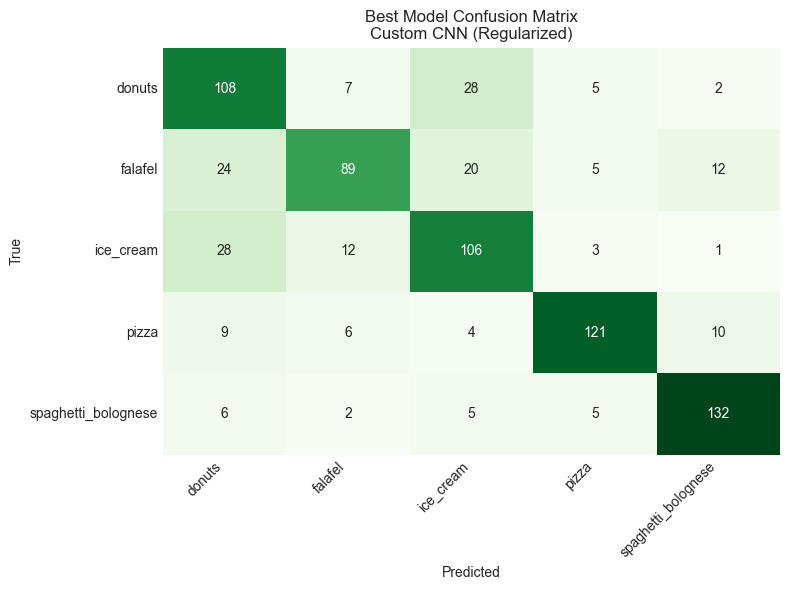

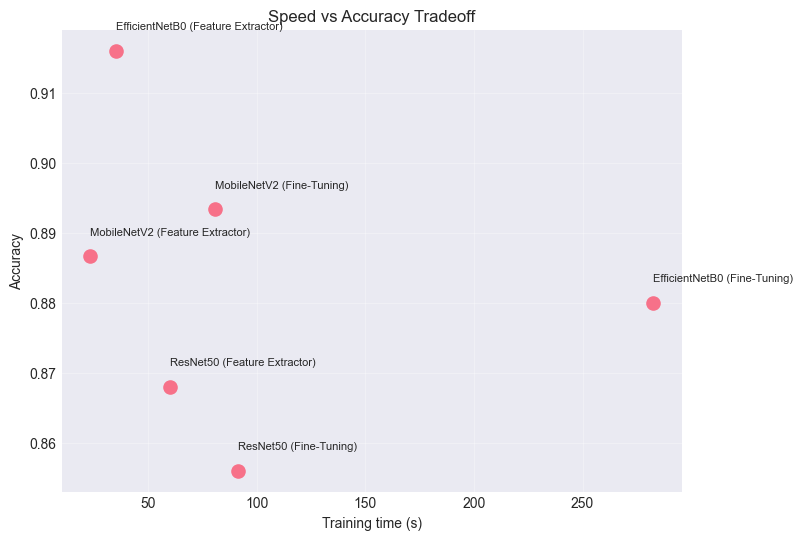

In [26]:
# Stage 6 - Confusion matrices, weakest classes, misclassifications, and tradeoff analysis
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use stored transfer-learning metrics from Stage 5 and live baseline models from Stages 2/3.

def build_eval_row(name, acc, train_time=np.nan, gap=np.nan, y_pred=None):
    return {
        'Model': name,
        'Accuracy': float(acc),
        'Training time (s)': float(train_time) if train_time == train_time else np.nan,
        'Overfitting gap (train - best val)': float(gap) if gap == gap else np.nan,
        'y_pred': y_pred,
    }

rows = []

if 'custom_cnn' in globals() and 'X_test' in globals() and 'y_test' in globals():
    y_pred = np.argmax(custom_cnn.predict(X_test, verbose=0), axis=1)
    gap = final_train_acc - val_acc if 'final_train_acc' in globals() and 'val_acc' in globals() else np.nan
    rows.append(build_eval_row('Custom CNN (Baseline)', accuracy_score(y_test, y_pred), gap=gap, y_pred=y_pred))

if 'regularized_cnn' in globals() and 'X_test' in globals() and 'y_test' in globals():
    y_pred = np.argmax(regularized_cnn.predict(X_test, verbose=0), axis=1)
    gap = final_train_reg - val_acc_reg if 'final_train_reg' in globals() and 'val_acc_reg' in globals() else np.nan
    rows.append(build_eval_row('Custom CNN (Regularized)', accuracy_score(y_test, y_pred), gap=gap, y_pred=y_pred))

# Add Stage 5 models from tl_results.
for key, r in tl_results.items():
    rows.append(build_eval_row(
        f"{r['model_label']} ({r['experiment']})",
        r['acc'],
        train_time=r['train_time'],
        gap=max(r['history'].get('accuracy', [np.nan])) - max(r['history'].get('val_accuracy', [np.nan])) if 'history' in r else np.nan,
        y_pred=None,
    ))

if len(rows) == 0:
    print('No trained models found. Run Stage 2/3/5 cells first.')
else:
    results_df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
    print('Stage 6 - Model Comparison')
    display(results_df[['Model', 'Accuracy', 'Training time (s)', 'Overfitting gap (train - best val)']].round(4))

    best_model_name = results_df.iloc[0]['Model']
    print('Best-performing model (by Accuracy):', best_model_name)

    # Only plot confusion matrices for models that have predictions saved in this cell.
    pred_rows = results_df[results_df['y_pred'].notna()].copy()
    if len(pred_rows) > 0:
        best_pred = pred_rows.iloc[0]['y_pred']
        cm_best = confusion_matrix(y_test, best_pred)

        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax)
        ax.set_title('Best Model Confusion Matrix\n' + pred_rows.iloc[0]['Model'])
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_xticklabels(class_names, rotation=45, ha='right')
        ax.set_yticklabels(class_names, rotation=0)
        plt.tight_layout()
        plt.show()
    else:
        print('Confusion matrix skipped because predictions were not stored for transfer-learning models.')

    speed_df = results_df.dropna(subset=['Training time (s)']).copy()
    if len(speed_df) > 0:
        plt.figure(figsize=(8, 6))
        plt.scatter(speed_df['Training time (s)'], speed_df['Accuracy'], s=90)
        for _, row in speed_df.iterrows():
            plt.text(row['Training time (s)'], row['Accuracy'] + 0.003, row['Model'], fontsize=8)
        plt.xlabel('Training time (s)')
        plt.ylabel('Accuracy')
        plt.title('Speed vs Accuracy Tradeoff')
        plt.grid(alpha=0.3)
        plt.show()


## Augmented Image Samples

This visualization shows one original training image and multiple augmented versions generated by the Stage 3 augmentation pipeline.

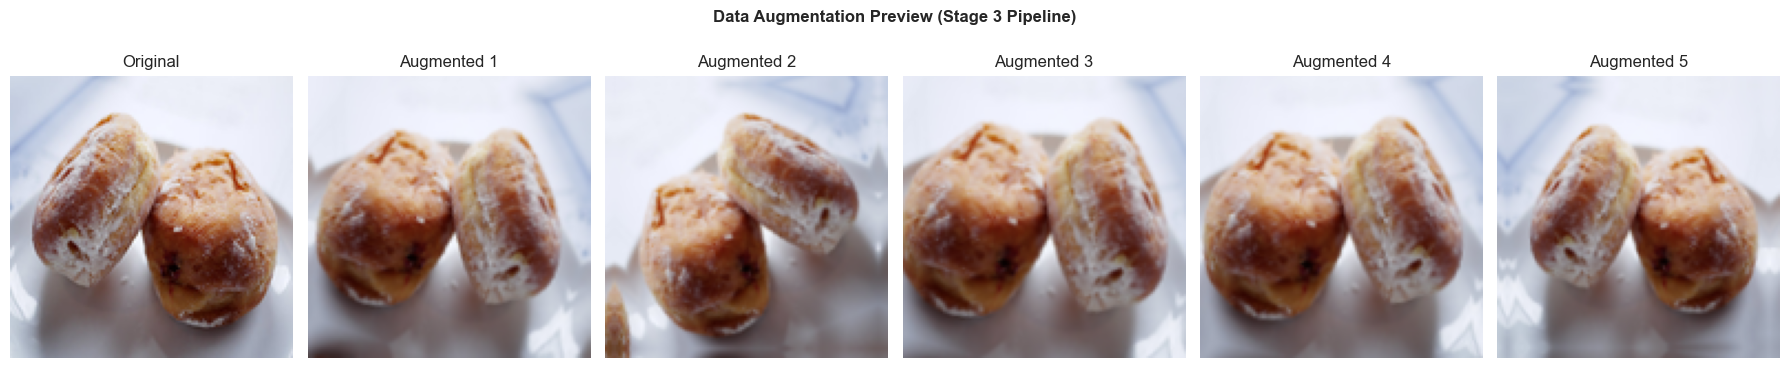

In [27]:
# This cell visualizes data augmentation outputs required in the report.
# It shows one original image and several augmented variants.

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

if 'data_augmentation' not in globals():
    print("data_augmentation is not defined. Run the Stage 3 setup cell first.")
elif 'X_train' not in globals() or len(X_train) == 0:
    print("X_train is not available. Run the data loading/splitting cells first.")
else:
    # Pick one sample image from training data
    sample_idx = 0
    original_img = X_train[sample_idx]

    # Generate augmented versions of the same image
    n_augmented = 5
    augmented_imgs = []
    for _ in range(n_augmented):
        aug = data_augmentation(tf.expand_dims(original_img, axis=0), training=True)
        augmented_imgs.append(tf.squeeze(aug, axis=0).numpy())

    # Plot: original + augmented images
    fig, axes = plt.subplots(1, n_augmented + 1, figsize=(18, 4))
    axes[0].imshow(np.clip(original_img, 0, 1))
    axes[0].set_title("Original")
    axes[0].axis("off")

    for i in range(n_augmented):
        axes[i + 1].imshow(np.clip(augmented_imgs[i], 0, 1))
        axes[i + 1].set_title(f"Augmented {i+1}")
        axes[i + 1].axis("off")

    plt.suptitle("Data Augmentation Preview (Stage 3 Pipeline)", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()